In [3]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from cmcrameri import cm
import cartopy
import cartopy.crs as ccrs
from cartopy.io.shapereader import Reader
import xesmf as xe # for regridding data
import rioxarray
import gc # garbage collection

In [4]:
# coordinates for region of interest
min_lat_plotting = -22.
max_lat_plotting = 12.
min_lon_plotting = 360.-82.
max_lon_plotting = 360.-42.

geog_range_plotting = [min_lon_plotting, max_lon_plotting, min_lat_plotting, max_lat_plotting]
print(geog_range_plotting)

[278.0, 318.0, -22.0, 12.0]


In [5]:
# shapefile for Amazon ecoregion
Amazon_shapefile='/global/homes/j/jkowalcz/shapefileamazonecoregionwwf/amazon_ecolola.shp'

--- Spatial Metadata for /pscratch/sd/j/jkowalcz/e3sm_scratch/pm-cpu/Benchmarks/GOSIF/GOSIF_GPP_2001_Mean.tif ---
Coordinate Reference System (CRS): EPSG:4326
Bounds (minx, miny, maxx, maxy): (-180.0, -90.00000000000003, 180.00000000000006, 90.0)
Width/Height: 7200 x 3600
Number of Bands: 1
Resolution (pixel size): (0.05, -0.05)

Generating low-res preview...


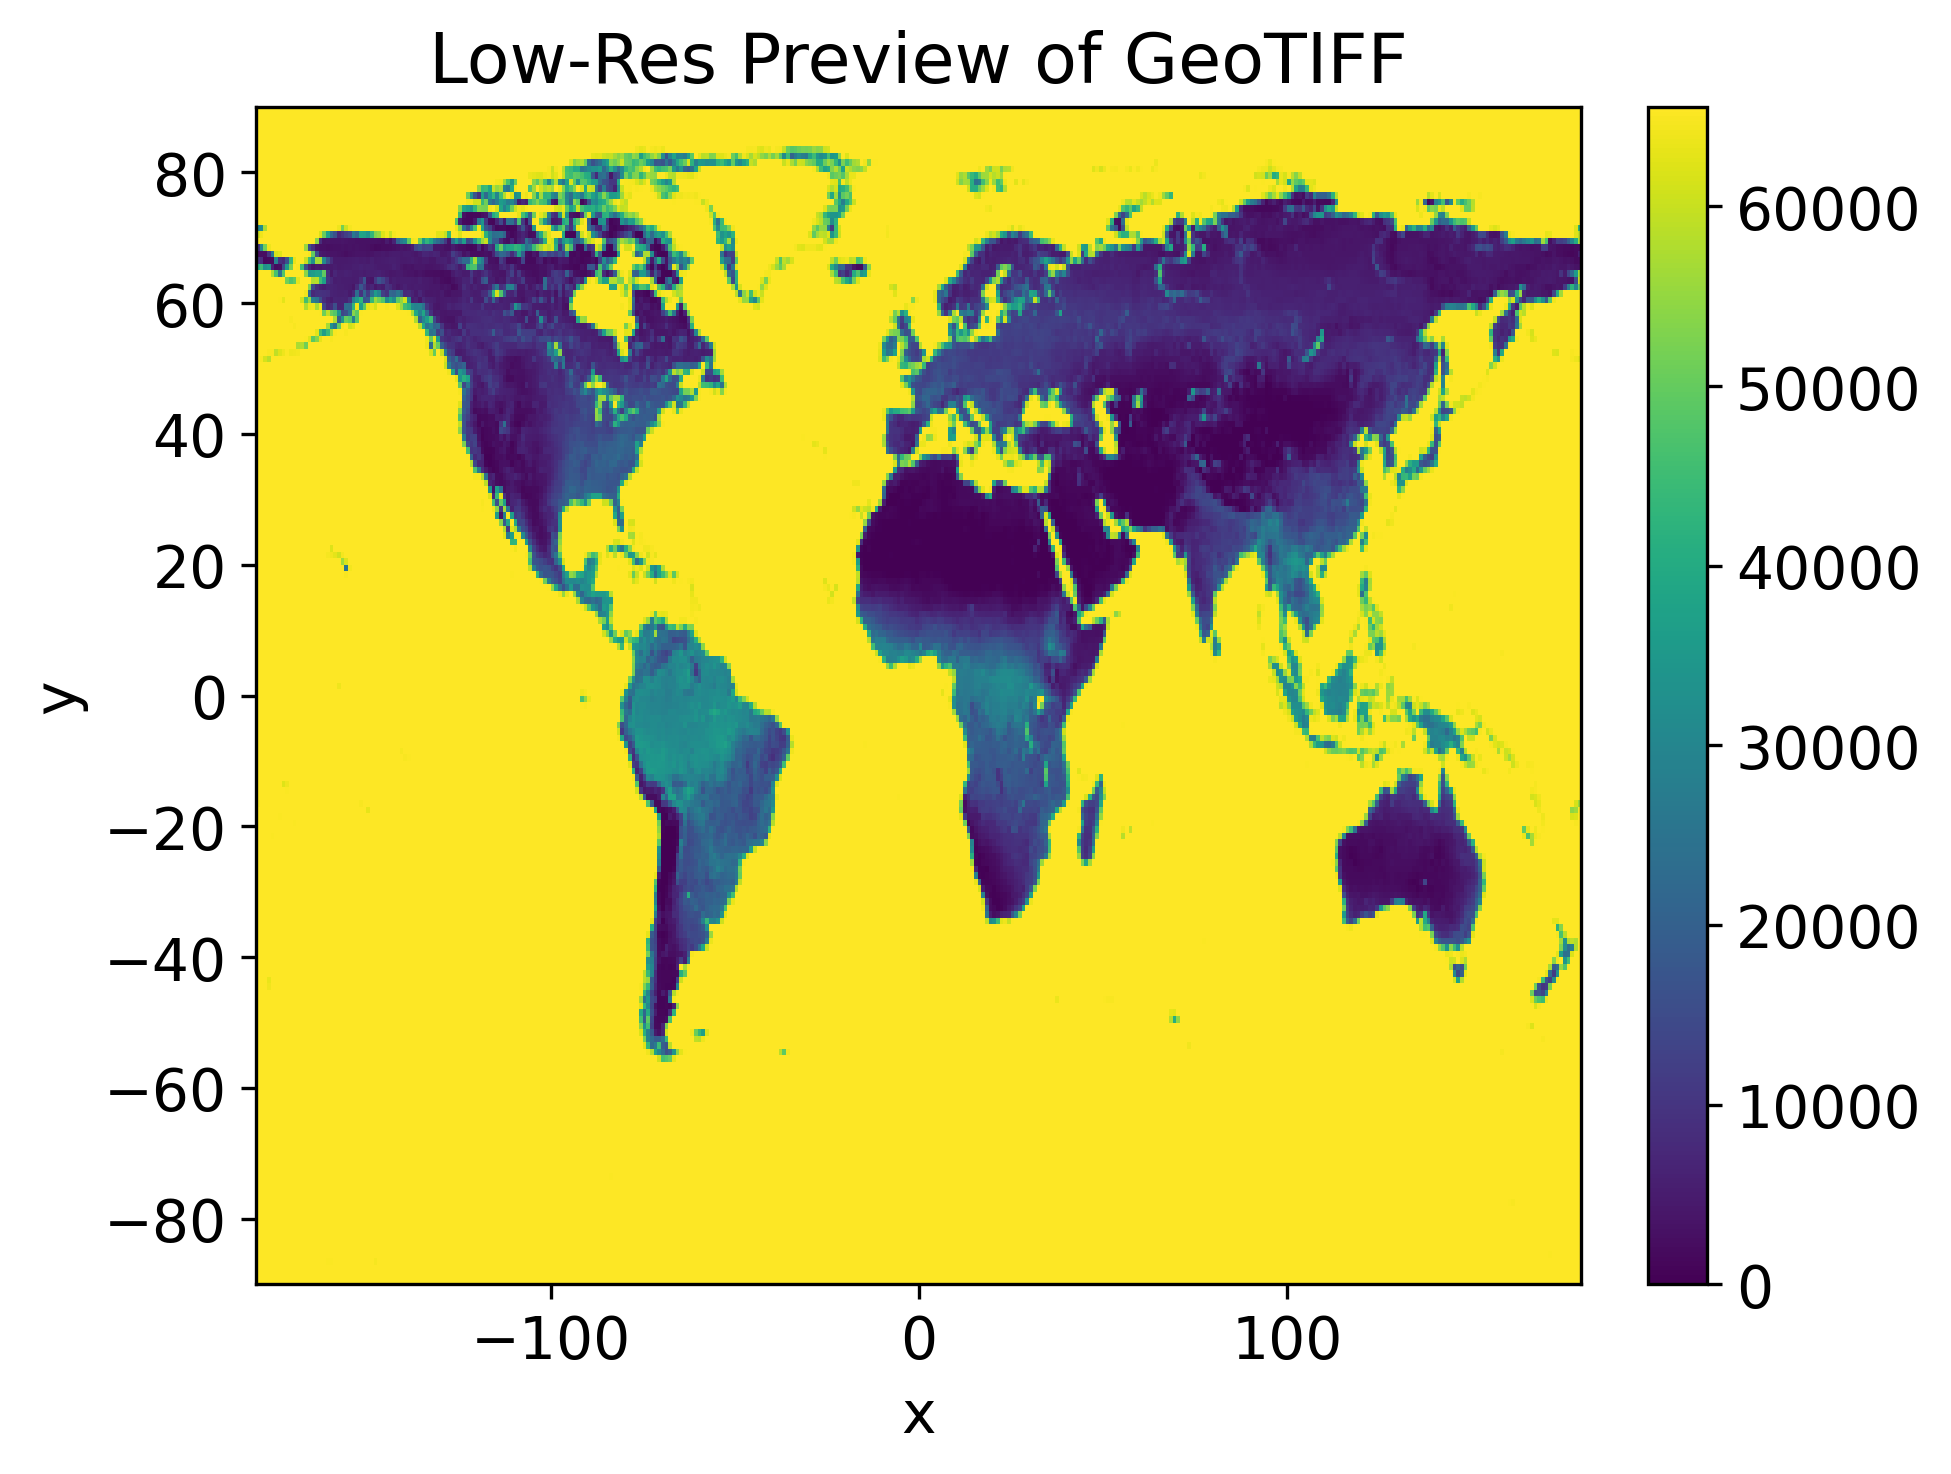

In [6]:
## Look at one GeoTIFF file to see what coordinate system is

## code by Google Gemini

# 1. Load the file (lazily, so it doesn't eat your RAM)
file_path = "/pscratch/sd/j/jkowalcz/e3sm_scratch/pm-cpu/Benchmarks/GOSIF/GOSIF_GPP_2001_Mean.tif"
rds = rioxarray.open_rasterio(file_path, chunks=True)

# 2. Print the spatial "ID Card"
print(f"--- Spatial Metadata for {file_path} ---")
print(f"Coordinate Reference System (CRS): {rds.rio.crs}")
print(f"Bounds (minx, miny, maxx, maxy): {rds.rio.bounds()}")
print(f"Width/Height: {rds.rio.width} x {rds.rio.height}")
print(f"Number of Bands: {rds.rio.count}")
print(f"Resolution (pixel size): {rds.rio.resolution()}")

# 3. Quick Visual Look
# We 'coarsen' the data by a factor of 20 just for the plot 
# so it displays instantly.
print("\nGenerating low-res preview...")
rds.sel(band=1).coarsen(x=20, y=20, boundary='trim').mean().plot(cmap="viridis")

plt.title("Low-Res Preview of GeoTIFF")
plt.show()

In [6]:
## subset files for Amazon and average over 2000-2014
## code by Google Gemini

def average_regional_subset(input_dir, output_file, bounds):
    """
    Masks water to NaN, subsets by bounds, and averages across all files.
    """
    tiff_files = [os.path.join(input_dir, f) for f in os.listdir(input_dir) if f.endswith('_Mean.tif')]
    
    if not tiff_files:
        print("No files found.")
        return

    subset_list = []
    
    for f in tiff_files:
        # 1. Open lazily
        ds = rioxarray.open_rasterio(f, chunks={'x': 1000, 'y': 1000})
        
        # 2. Subset first (saves memory by masking a smaller area)
        subset = ds.rio.clip_box(*bounds)
        
        # 3. # Replace 65535 (water) with NaN in each DataArray 
        # This converts the data to float if it wasn't already
        subset = subset.where(subset != 65535,np.nan)
        subset_list.append(subset)

    # 4. Stack and Mean
    stack = xr.concat(subset_list, dim="stack")
    regional_average = stack.mean(dim="stack", skipna=True)
    
    # 5. Save
    # Note: Added os.path.join for cleaner path handling
    full_output_path = os.path.join(input_dir, output_file)
    regional_average.rio.to_raster(full_output_path)
    
    print(f"Regional average (masked and subsetted) saved to: {full_output_path}")


In [7]:
# minx, miny, maxx, maxy
bounds=(-82,-22,-42,12)
path='/pscratch/sd/j/jkowalcz/e3sm_scratch/pm-cpu/Benchmarks/GOSIF/'
outfile='gosif_gpp_regional_avg.tif'

In [15]:
### make regionally subset, average file. 
average_regional_subset(path,outfile,bounds)

Regional average (masked and subsetted) saved to: /pscratch/sd/j/jkowalcz/e3sm_scratch/pm-cpu/Benchmarks/GOSIF/regional_average.tif


In [8]:
gosif = rioxarray.open_rasterio(path+outfile)

In [9]:
gosif_avg_fx=gosif.rename({"y": "lat", "x": "lon"})

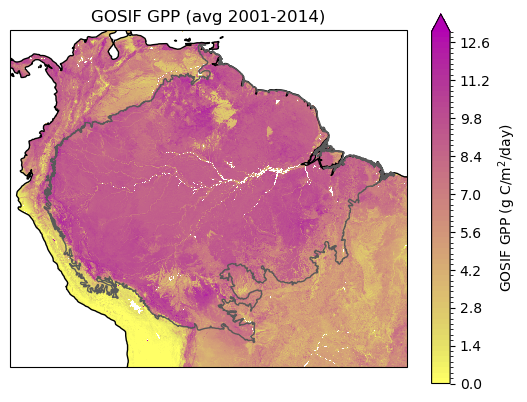

In [10]:
scale_factor=0.1 # for yearly data, from GOSIF documentation
# divide by 365 to convert from per year to per day

#GOSIF GPP 
ax = plt.subplot(projection=ccrs.PlateCarree())
gosif_avg_gpp=gosif_avg_fx*scale_factor/365.
gosif_avg_gpp.plot(x='lon', y='lat',levels=np.linspace(0,13,66),cmap=cm.buda_r,transform=ccrs.PlateCarree(),cbar_kwargs=dict(location='right',orientation='vertical',label='GOSIF GPP (g C/m$^2$/day)'))
plt.title("GOSIF GPP (avg 2001-2014)")
ax.coastlines()
ax.add_geometries(Reader(Amazon_shapefile).geometries(),ccrs.PlateCarree(),edgecolor=(0.35,0.35,0.35,1),facecolor=(0,0,0,0))
